In [1]:
!pip install wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [4]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


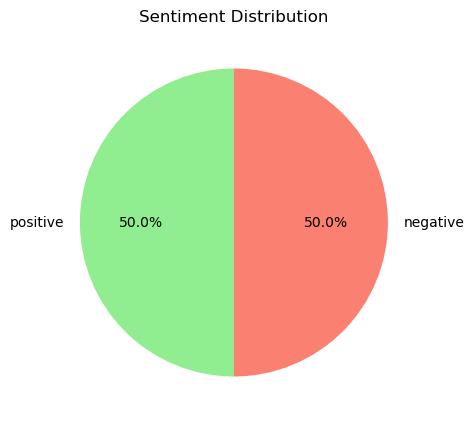

In [5]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

plt.figure(figsize=(5,5))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=['lightgreen', 'salmon'], startangle=90)
plt.title('Sentiment Distribution')
plt.show()

In [6]:
print(df['review'].iloc[0][:500])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ


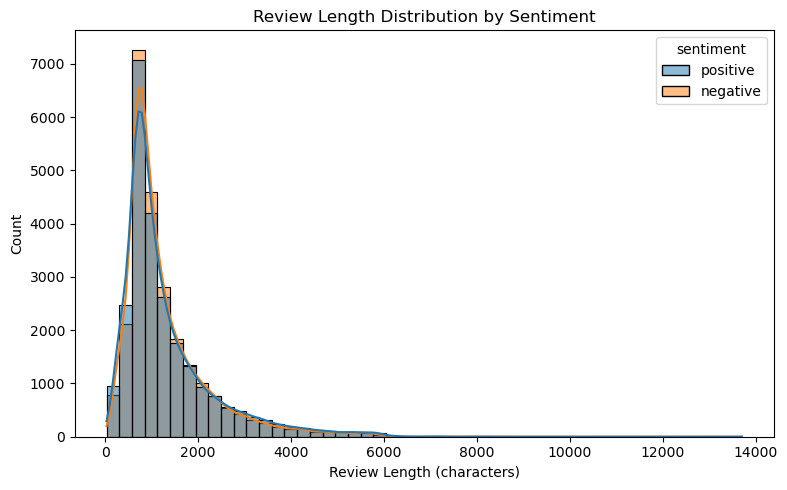

In [7]:
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='review_length', hue='sentiment', bins=50, kde=True)
plt.title('Review Length Distribution by Sentiment')
plt.xlabel('Review Length (characters)')
plt.tight_layout()
plt.show()

In [8]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)          
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)     
    text = text.lower()                          
    text = re.sub(r'\s+', ' ', text).strip()     
    return text

df['cleaned_review'] = df['review'].apply(clean_text)
df[['review', 'cleaned_review']].head(3)

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...


In [9]:
print("BEFORE:\n", df['review'].iloc[0][:300])
print("\n\nAFTER:\n", df['cleaned_review'].iloc[0][:300])

BEFORE:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru


AFTER:
 one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not 


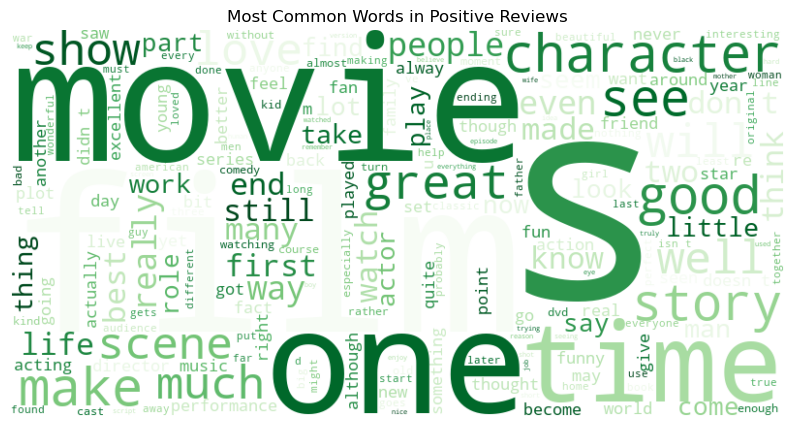

In [10]:
from wordcloud import WordCloud

positive_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'].sample(2000, random_state=42))

plt.figure(figsize=(10,6))
wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews')
plt.show()

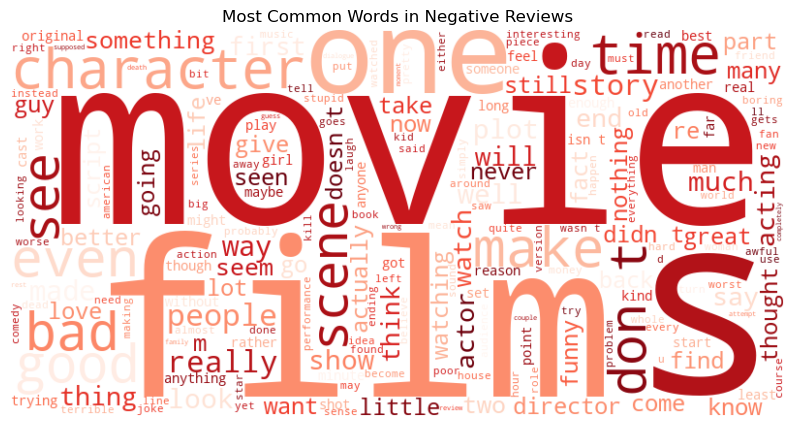

In [11]:
negative_text = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'].sample(2000, random_state=42))

plt.figure(figsize=(10,6))
wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews')
plt.show()

In [12]:
df['sentiment_encoded'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df[['sentiment', 'sentiment_encoded']].head()

,sentiment,sentiment_encoded
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [13]:
from sklearn.model_selection import train_test_split

X = df['cleaned_review']
y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 40000
Test size: 10000


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

TF-IDF matrix shape (train): (40000, 5000)


In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_tfidf, y_train)

log_preds = log_model.predict(X_test_tfidf)
print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [16]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_test_tfidf)
print("Naive Bayes trained successfully!")

Naive Bayes trained successfully!


In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, log_preds), 4))
print(classification_report(y_test, log_preds, target_names=['Negative', 'Positive']))

print("\n=== Naive Bayes ===")
print("Accuracy:", round(accuracy_score(y_test, nb_preds), 4))
print(classification_report(y_test, nb_preds, target_names=['Negative', 'Positive']))

=== Logistic Regression ===
Accuracy: 0.8894
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


=== Naive Bayes ===
Accuracy: 0.8541
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85      5000
    Positive       0.85      0.86      0.86      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



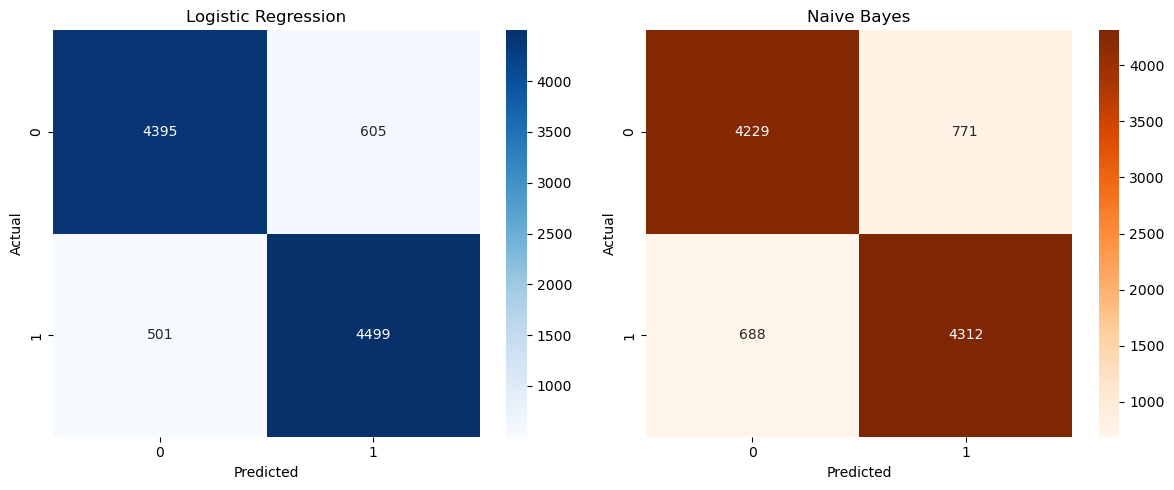

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, log_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Naive Bayes')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [19]:
def predict_sentiment(text, model=log_model):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    return "Positive" if prediction == 1 else "Negative"

# Examples
print(predict_sentiment("This movie was absolutely wonderful, I loved every minute of it!"))
print(predict_sentiment("Terrible film, complete waste of time and money."))

Positive
Negative


In [20]:
df[['review', 'cleaned_review', 'sentiment']].to_csv('cleaned_movie_reviews.csv', index=False)
print("Cleaned dataset saved as 'cleaned_movie_reviews.csv'")

Cleaned dataset saved as 'cleaned_movie_reviews.csv'
